In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [5]:
df=pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [7]:
df.shape

(200, 4)

In [8]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [11]:
x=df[['TV','Radio','Newspaper']] # input 
y=df['Sales'] # output 

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [13]:
model=LinearRegression()

In [14]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
prediction=model.predict(x_test)

In [16]:
prediction[:5]

array([13.38344822, 21.33304673, 18.46954139, 17.62025766, 10.92142341])

## Actual vs Predicted

In [17]:
comparison=pd.DataFrame({
    "Actual":y_test,
    "prediction":prediction
})

comparison

,Actual,prediction
16,12.5,13.383448
93,22.2,21.333047
14,19.0,18.469541
169,15.0,17.620258
126,6.6,10.921423
13,9.7,8.760404
115,12.6,13.171072
108,5.3,3.708916
146,13.2,15.037087
156,15.3,15.620628


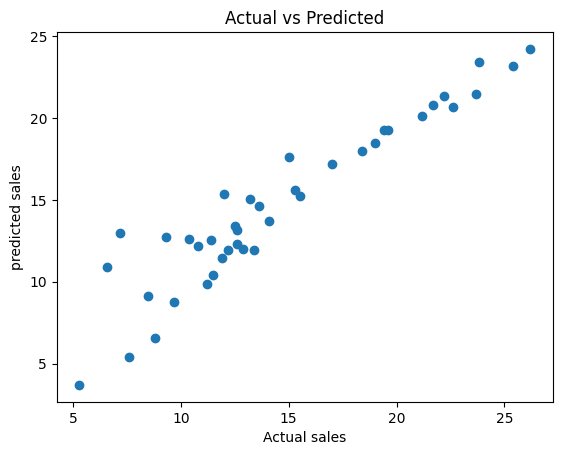

In [18]:
plt.scatter(y_test,prediction)
plt.ylabel("predicted sales")
plt.xlabel("Actual sales")

plt.title("Actual vs Predicted")
plt.show()

In [19]:
from sklearn.metrics import r2_score
score=r2_score(y_test,prediction)
score

0.8861252621043765

## Model Evaluation

The performance of the Linear Regression model is evaluated using the following metrics:

- **MAE (Mean Absolute Error):** Measures the average prediction error.
- **MSE (Mean Squared Error):** Measures the average squared prediction error.
- **RMSE (Root Mean Squared Error):** Indicates the standard deviation of prediction errors.
- **R² Score:** Measures how well the model explains the variance in the target variable.

The following code calculates these metrics on the test dataset.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, prediction))
print("MSE:", mean_squared_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score:", r2_score(y_test, prediction))

MAE: 1.4048684486608352
MSE: 3.427196174937154
RMSE: 1.8512688013730352
R2 Score: 0.8861252621043765


## Exploratory Data Analysis (EDA)

To understand the relationship between advertising expenditure and sales, scatter plots are created for each advertising channel.



## TV vs Sales

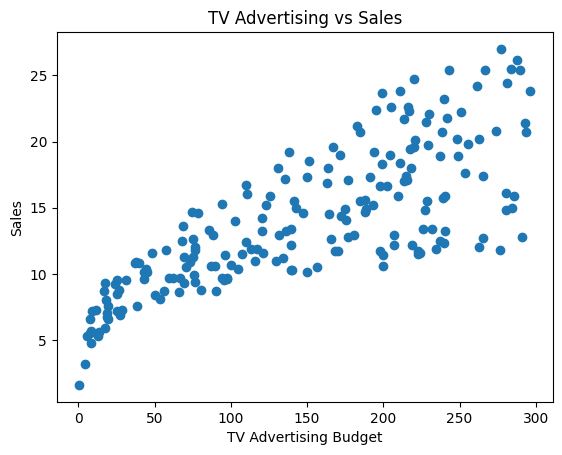

In [21]:

plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.show()

## Radio vs Sales

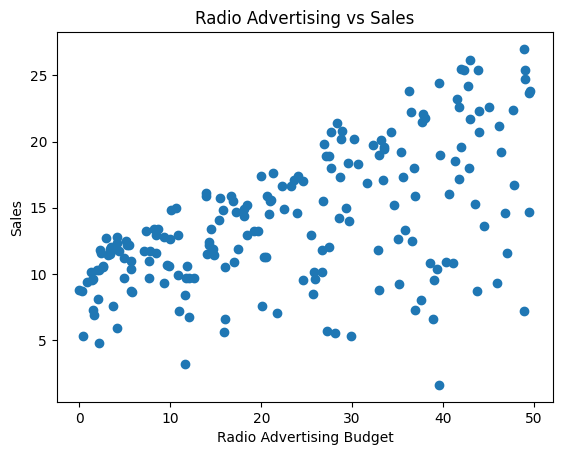

In [22]:

plt.scatter(df['Radio'], df['Sales'])
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales')
plt.title('Radio Advertising vs Sales')
plt.show()

## Newspaper vs Sales

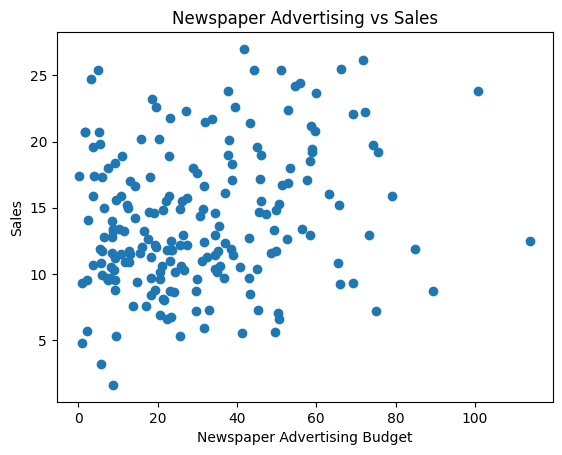

In [23]:

plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel('Newspaper Advertising Budget')
plt.ylabel('Sales')
plt.title('Newspaper Advertising vs Sales')
plt.show()